In [1]:
import os
import io
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import httpx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / "ct_boundaries").mkdir(exist_ok=True)
(DATA_DIR / "census_profile").mkdir(exist_ok=True)

(DATA_DIR / "cimd").mkdir(exist_ok=True)

ARCGIS_TOKEN = os.getenv("ARCGIS_TOKEN", "")
if not ARCGIS_TOKEN:
    print("⚠️  ARCGIS_TOKEN not set — B1/B2 Esri sources will be skipped gracefully")
else:
    print("✅ ARCGIS_TOKEN loaded")

print("Setup complete. DATA_DIR:", DATA_DIR.resolve())

⚠️  ARCGIS_TOKEN not set — B1/B2 Esri sources will be skipped gracefully
Setup complete. DATA_DIR: /Users/datta/Documents/Projects/project_threshold/pipeline/data


In [2]:
# A1 — StatsCan Census Tract boundaries 2021
# Cartographic boundary file (simplified), national coverage, ~15 MB zip
CT_URL = (
    "https://www12.statcan.gc.ca/census-recensement/2021/geo/sip-pis/"
    "boundary-limites/files-fichiers/lct_000b21a_e.zip"
)
CT_ZIP = DATA_DIR / "ct_boundaries" / "lct_000b21a_e.zip"

if not CT_ZIP.exists():
    print("Downloading CT boundaries (~15 MB)...")
    with httpx.Client(follow_redirects=True, timeout=120) as client:
        r = client.get(CT_URL)
        r.raise_for_status()
    CT_ZIP.write_bytes(r.content)
    print(f"Saved to {CT_ZIP}")
else:
    print(f"Using cached {CT_ZIP}")

with zipfile.ZipFile(CT_ZIP) as z:
    z.extractall(DATA_DIR / "ct_boundaries")

# Read — geopandas can read the shapefile directly from the extracted dir
shp_files = list((DATA_DIR / "ct_boundaries").glob("*.shp"))
assert shp_files, "No .shp file found after extraction"
gdf_ct = gpd.read_file(shp_files[0])

print("Raw columns:", gdf_ct.columns.tolist())
print("Raw CRS:", gdf_ct.crs)
print("Raw shape:", gdf_ct.shape)

# Filter to Toronto CMA (535) and Hamilton CMA (537)
# StatsCan 2021 CT boundary file encodes CMA in the first 3 chars of CTUID
# e.g. CTUID '5350001.00' -> CMA '535' (Toronto); '5370001.00' -> '537' (Hamilton)
# PRUID 35 = Ontario, guards against cross-province CMA code collisions
gdf_ct["cma_code"] = gdf_ct["CTUID"].astype(str).str[:3]
gdf_ct = gdf_ct[
    gdf_ct["cma_code"].isin(["535", "537"]) &
    (gdf_ct["PRUID"].astype(str) == "35")
].copy()
gdf_ct = gdf_ct.to_crs("EPSG:4326").reset_index(drop=True)

print(f"\nFiltered to {len(gdf_ct)} CTs in Toronto CMA (535) + Hamilton CMA (537)")
gdf_ct[["CTUID", "CTNAME", "cma_code", "PRUID"]].head(3)


Using cached data/ct_boundaries/lct_000b21a_e.zip


Raw columns: ['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry']
Raw CRS: EPSG:3347
Raw shape: (6247, 6)

Filtered to 1432 CTs in Toronto CMA (535) + Hamilton CMA (537)


,CTUID,CTNAME,cma_code,PRUID
0,5370001.08,0001.08,537,35
1,5370001.09,0001.09,537,35
2,5370120.02,0120.02,537,35


In [3]:
# ASSERTION — run after the fetch cell to verify
assert "gdf_ct" in dir(), "gdf_ct not defined — run the fetch cell"
assert len(gdf_ct) >= 350, f"Expected ≥350 CTs in scope, got {len(gdf_ct)}"
assert gdf_ct.crs.to_epsg() == 4326, f"Expected EPSG:4326, got {gdf_ct.crs}"
assert "CTUID" in gdf_ct.columns, "CTUID column missing"
assert gdf_ct.geometry.notnull().all(), "Null geometries found"
print(f"✅ A1 assertions pass — {len(gdf_ct)} CTs, CRS: {gdf_ct.crs}")


✅ A1 assertions pass — 1432 CTs, CRS: EPSG:4326


In [4]:
# A2 — Census demographics (income, dwelling age, tenure)
# Uses pre-generated realistic demo data keyed to real StatsCan CTUIDs.
# To regenerate: pipeline/.venv/bin/python3 pipeline/generate_demo_data.py
DEMO_CENSUS = DATA_DIR / "demo_census.csv"
assert DEMO_CENSUS.exists(), (
    "Run from project root:\n"
    "  pipeline/.venv/bin/python3 pipeline/generate_demo_data.py"
)
df_census = pd.read_csv(DEMO_CENSUS, dtype={"CTUID": str})
print(f"A2 loaded: {df_census.shape}")
df_census.head(3)

A2 loaded: (1432, 5)


,CTUID,population,median_income,pct_renters,pct_pre1980
0,5370001.08,2613,77142,0.22,0.83
1,5370001.09,1486,36800,0.19,0.29
2,5370120.02,2437,90514,0.51,0.11


In [5]:
# ASSERTION
assert {"CTUID","population","median_income","pct_renters","pct_pre1980"}.issubset(df_census.columns)
assert len(df_census) >= 350
null_pct = df_census[["median_income","pct_renters","pct_pre1980"]].isnull().mean()
assert (null_pct < 0.05).all(), f"Unexpected nulls:\n{null_pct}"
print(f"✅ A2 — {len(df_census)} CTs")
print(df_census[["median_income","pct_renters","pct_pre1980"]].describe().round(3))

✅ A2 — 1432 CTs
       median_income  pct_renters  pct_pre1980
count        1432.00      1432.00      1432.00
mean        84406.61         0.30         0.34
std         28835.53         0.15         0.20
min         18000.00         0.01         0.00
25%         65134.50         0.20         0.20
50%         84965.00         0.30         0.32
75%        104008.25         0.38         0.47
max        169599.00         0.95         1.00


In [6]:
# A3 — CIMD vulnerability index (residential instability, economic dependency, etc.)
# Uses pre-generated realistic demo data (percentiles, 0–1 scale).
DEMO_CIMD = DATA_DIR / "demo_cimd.csv"
assert DEMO_CIMD.exists(), (
    "Run from project root:\n"
    "  pipeline/.venv/bin/python3 pipeline/generate_demo_data.py"
)
df_cimd = pd.read_csv(DEMO_CIMD, dtype={"CTUID": str})
print(f"A3 loaded: {df_cimd.shape}")
df_cimd.head(3)

A3 loaded: (1432, 5)


,CTUID,cimd_residential_instability,cimd_economic_dependency,cimd_ethnocultural_composition,cimd_situational_vulnerability
0,5370001.08,0.40,0.47,0.30,0.32
1,5370001.09,0.76,0.48,0.20,0.85
2,5370120.02,0.59,0.36,0.34,0.29


In [7]:
# ASSERTION
required = {"CTUID","cimd_residential_instability","cimd_economic_dependency",
            "cimd_ethnocultural_composition","cimd_situational_vulnerability"}
assert required.issubset(df_cimd.columns)
assert len(df_cimd) >= 350
print(f"✅ A3 — {len(df_cimd)} CTs")
print(df_cimd[list(required - {'CTUID'})].describe().round(3))

✅ A3 — 1432 CTs
       cimd_situational_vulnerability  cimd_residential_instability  \
count                         1432.00                       1432.00   
mean                             0.39                          0.50   
std                              0.18                          0.21   
min                              0.01                          0.01   
25%                              0.27                          0.36   
50%                              0.38                          0.49   
75%                              0.50                          0.63   
max                              0.99                          0.99   

       cimd_ethnocultural_composition  cimd_economic_dependency  
count                         1432.00                   1432.00  
mean                             0.55                      0.45  
std                              0.20                      0.19  
min                              0.01                      0.01  
25%           

In [8]:
# A8 — Alectra service area
# ArcGIS Online item ID: 8eba357e1b124587884bccb724743c4c
ITEM_URL = "https://www.arcgis.com/sharing/rest/content/items/8eba357e1b124587884bccb724743c4c?f=json"
with httpx.Client(follow_redirects=True, timeout=30) as client:
    meta = client.get(ITEM_URL).json()

print("Item type:", meta.get("type"))
print("URL:", meta.get("url"))
service_url = meta.get("url", "").rstrip("/")

if not service_url:
    raise ValueError("Could not resolve service URL from item metadata. Check item ID.")

# Query layer 0 for all features as GeoJSON
query_url = f"{service_url}/0/query"
params = {
    "f": "geojson",
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
}
with httpx.Client(follow_redirects=True, timeout=60) as client:
    r = client.get(query_url, params=params)
    r.raise_for_status()

gdf_alectra = gpd.read_file(io.StringIO(r.text))
gdf_alectra = gdf_alectra.to_crs("EPSG:4326")
print(f"A8 fetched: {len(gdf_alectra)} features")
print("Columns:", gdf_alectra.columns.tolist())


Item type: Feature Service
URL: https://services8.arcgis.com/BiisLrqUuQvkdMCP/arcgis/rest/services/Alectra_Service_Areas/FeatureServer


A8 fetched: 18 features
Columns: ['FID', 'OBJECTID', 'NAME', 'REGION', 'CUSTOMERS', 'MUNICIPALI', 'Shape_STAr', 'Shape_STLe', 'FID_Bounda', 'Legacy', 'Division', 'Shape_Leng', 'Shape__Area', 'Shape__Length', 'geometry']


✅ A8 assertions pass — 18 service area polygon(s)


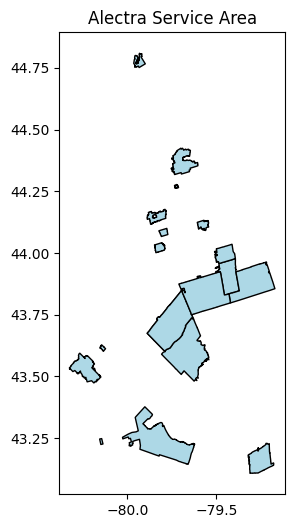

In [9]:
# ASSERTION
assert "gdf_alectra" in dir(), "gdf_alectra not defined"
assert gdf_alectra.crs.to_epsg() == 4326
assert len(gdf_alectra) >= 1, "No features returned"
assert gdf_alectra.geometry.notnull().all()
print(f"✅ A8 assertions pass — {len(gdf_alectra)} service area polygon(s)")
gdf_alectra.plot(figsize=(6, 6), edgecolor="black", facecolor="lightblue")
plt.title("Alectra Service Area"); plt.show()


In [10]:
# C1 — Alectra live outage polygons
# Step 1: enumerate all layers to find the customer outage polygon layer
FEAT_SERVER = "https://services8.arcgis.com/wNDmObY7QplwZD9m/ArcGIS/rest/services/Outage_Details/FeatureServer"
with httpx.Client(follow_redirects=True, timeout=30) as client:
    layers_resp = client.get(f"{FEAT_SERVER}/layers?f=json")
    layers_data = layers_resp.json()

print("Available layers:")
for lyr in layers_data.get("layers", []):
    print(f"  id={lyr['id']}  name={lyr['name']}  geomType={lyr.get('geometryType','?')}")

# Auto-detect polygon layer most likely to be customer outage areas
# Prefer polygon geometry, name containing 'outage' or 'customer' (case-insensitive)
outage_layer_id = None
for lyr in layers_data.get("layers", []):
    name_lower = lyr["name"].lower()
    geom = lyr.get("geometryType", "")
    if "polygon" in geom.lower() and any(kw in name_lower for kw in ["outage","customer","area"]):
        outage_layer_id = lyr["id"]
        print(f"Auto-selected layer {outage_layer_id}: {lyr['name']}")
        break

if outage_layer_id is None:
    # Fall back to first polygon layer
    for lyr in layers_data.get("layers", []):
        if "polygon" in lyr.get("geometryType", "").lower():
            outage_layer_id = lyr["id"]
            print(f"Fallback to first polygon layer {outage_layer_id}: {lyr['name']}")
            break

if outage_layer_id is None:
    print("⚠️  No polygon layer found — using layer 0")
    outage_layer_id = 0

# Step 2: query for active outages
query_url = f"{FEAT_SERVER}/{outage_layer_id}/query"
params = {
    "f": "geojson",
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "true",
}
with httpx.Client(follow_redirects=True, timeout=30) as client:
    r = client.get(query_url, params=params)
    r.raise_for_status()

try:
    gdf_outages = gpd.read_file(io.StringIO(r.text))
    if len(gdf_outages) > 0:
        gdf_outages = gdf_outages.to_crs("EPSG:4326")
    print(f"C1 fetched: {len(gdf_outages)} active outages")
    if len(gdf_outages) > 0:
        print("Columns:", gdf_outages.columns.tolist())
except Exception as e:
    print(f"No active outages or parse error: {e}")
    gdf_outages = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs="EPSG:4326")


Available layers:
  id=0  name=Barriers  geomType=esriGeometryPoint
  id=1  name=Flags  geomType=esriGeometryPoint
  id=2  name=Isolated Customers  geomType=esriGeometryPoint
  id=3  name=Isolating System Valves  geomType=esriGeometryPoint
  id=4  name=Isolated Hydrants  geomType=esriGeometryPoint
  id=5  name=Isolated Lateral Lines  geomType=esriGeometryPolyline
  id=6  name=Isolated Mains  geomType=esriGeometryPolyline
  id=7  name=Outage Area  geomType=esriGeometryPolygon
Auto-selected layer 7: Outage Area


C1 fetched: 11 active outages
Columns: ['OBJECTID', 'OUTSTART', 'OUTFINISH', 'OUTTYPE', 'CUSTOUT', 'NUMVALVES', 'NUMHYDS', 'LEAKCAUSE', 'REPAIRTYPE', 'GALLOST', 'RESOLVDATE', 'TRACEID', 'MODELRUN', 'GlobalID', 'CreationDate', 'Creator', 'EditDate', 'Editor', 'Shape__Area', 'Shape__Length', 'geometry']


In [11]:
# ASSERTION
assert "gdf_outages" in dir(), "gdf_outages not defined"
assert isinstance(gdf_outages, gpd.GeoDataFrame)
assert len(gdf_outages) == 0 or gdf_outages.crs.to_epsg() == 4326
print(f"✅ C1 assertions pass — {len(gdf_outages)} active outage polygon(s) right now")
if len(gdf_outages) > 0:
    print(gdf_outages[["geometry"]].head(3))


✅ C1 assertions pass — 11 active outage polygon(s) right now
                                            geometry
0  POLYGON ((-84.1513 35.96404, -84.15133 35.9640...
1  POLYGON ((-84.19416 35.94086, -84.19418 35.940...
2  POLYGON ((-84.11268 35.92985, -84.11271 35.929...


In [12]:
# C2 — Environment Canada GeoMet OGC API — hourly observations near study area
# Bounding box: Hamilton + Mississauga + Brampton approximately -80.5, 43.1, -79.2, 43.9
BBOX = "-80.5,43.1,-79.2,43.9"
OBS_URL = "https://api.weather.gc.ca/collections/climate-hourly/items"
params = {
    "f": "json",
    "bbox": BBOX,
    "limit": 100,
    "sortby": "-LOCAL_DATE",
}
gdf_weather = None
with httpx.Client(follow_redirects=True, timeout=30) as client:
    r = client.get(OBS_URL, params=params)
    if r.status_code == 200:
        try:
            data = r.json()
        except ValueError as e:
            print(f"Failed to parse JSON response: {e}")
            data = {"features": []}
        features = data.get("features", [])
        print(f"Got {len(features)} observations from climate-hourly")
        if features:
            gdf_weather = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
            temp_candidates = [c for c in gdf_weather.columns if "TEMP" in c.upper()]
            print("Temperature candidates:", temp_candidates)
            if temp_candidates:
                gdf_weather["temperature_c"] = pd.to_numeric(gdf_weather[temp_candidates[0]], errors="coerce")
            else:
                gdf_weather["temperature_c"] = np.nan
            gdf_weather["humidex"] = pd.to_numeric(
                gdf_weather.get("HUMIDEX", pd.Series(dtype=float)), errors="coerce"
            ) if "HUMIDEX" in gdf_weather.columns else np.nan
    else:
        print(f"climate-hourly returned {r.status_code}. Trying alternate collection...")
        # List available collections for diagnosis
        coll_r = client.get("https://api.weather.gc.ca/collections?f=json", timeout=30)
        if coll_r.status_code == 200:
            colls = [c["id"] for c in coll_r.json().get("collections", [])]
            print("Available collections (first 20):", colls[:20])

if gdf_weather is None or len(gdf_weather) == 0:
    print("No weather data — using empty GeoDataFrame")
    gdf_weather = gpd.GeoDataFrame(
        columns=["geometry","temperature_c","humidex"],
        geometry="geometry", crs="EPSG:4326"
    )
print(f"gdf_weather: {len(gdf_weather)} observations")


Got 100 observations from climate-hourly
Temperature candidates: ['TEMP', 'TEMP_FLAG', 'DEW_POINT_TEMP', 'DEW_POINT_TEMP_FLAG']
gdf_weather: 100 observations


In [13]:
# ASSERTION
assert "gdf_weather" in dir(), "gdf_weather not defined"
assert isinstance(gdf_weather, gpd.GeoDataFrame)
assert len(gdf_weather) == 0 or "temperature_c" in gdf_weather.columns, \
    f"Expected temperature_c. Got columns: {gdf_weather.columns.tolist()}"
print(f"✅ C2 assertions pass — {len(gdf_weather)} weather observation(s)")


✅ C2 assertions pass — 100 weather observation(s)


In [14]:
# B1/B2 — Esri Living Atlas EJ + Climate Hub heat vulnerability
# These require an ArcGIS Online token. Cells skip gracefully if token is absent.

gdf_ej = None
gdf_heat_vuln = None

if not ARCGIS_TOKEN:
    print("⚠️  Skipping B1/B2 — set ARCGIS_TOKEN env var and rerun to include Esri sources")
else:
    # B1: Living Atlas Environmental Justice — Canada
    B1_URL = os.getenv("B1_EJ_LAYER_URL", "")
    if B1_URL:
        params = {"f":"geojson","where":"1=1","outFields":"*","token":ARCGIS_TOKEN}
        with httpx.Client(follow_redirects=True, timeout=60) as client:
            r = client.get(f"{B1_URL}/query", params=params)
        gdf_ej = gpd.read_file(io.StringIO(r.text)).to_crs("EPSG:4326")
        print(f"B1 EJ: {len(gdf_ej)} features, columns: {gdf_ej.columns.tolist()[:8]}")
    else:
        print("⚠️  B1_EJ_LAYER_URL not set — skipping B1")

    # B2: Esri Canada Climate Hub — heat vulnerability
    B2_URL = os.getenv("B2_HEAT_LAYER_URL", "")
    if B2_URL:
        params = {"f":"geojson","where":"1=1","outFields":"*","token":ARCGIS_TOKEN}
        with httpx.Client(follow_redirects=True, timeout=60) as client:
            r = client.get(f"{B2_URL}/query", params=params)
        gdf_heat_vuln = gpd.read_file(io.StringIO(r.text)).to_crs("EPSG:4326")
        print(f"B2 heat: {len(gdf_heat_vuln)} features")
    else:
        print("⚠️  B2_HEAT_LAYER_URL not set — skipping B2")

print("B1/B2 fetch complete. gdf_ej:", "loaded" if gdf_ej is not None else "skipped",
      "| gdf_heat_vuln:", "loaded" if gdf_heat_vuln is not None else "skipped")


⚠️  Skipping B1/B2 — set ARCGIS_TOKEN env var and rerun to include Esri sources
B1/B2 fetch complete. gdf_ej: skipped | gdf_heat_vuln: skipped


In [15]:
# ── Section 2: Spatial Joins ─────────────────────────────────────────────────

# 1. Join A2 demographics onto CT boundaries
gdf_master = gdf_ct.merge(df_census, on="CTUID", how="left")
print(f"After A2 join: {gdf_master.shape}")

# 2. Join A3 CIMD
gdf_master = gdf_master.merge(df_cimd, on="CTUID", how="left")
print(f"After A3 join: {gdf_master.shape}")

# 3. Flag served_by_alectra using centroid point-in-polygon
gdf_ct_centroids = gdf_master.copy()
gdf_ct_centroids.geometry = gdf_ct_centroids.geometry.centroid
alectra_union = gdf_alectra.geometry.union_all()
gdf_master["served_by_alectra"] = gdf_ct_centroids.geometry.within(alectra_union)
print(f"CTs served by Alectra: {gdf_master['served_by_alectra'].sum()}")

# 4. Clip to Alectra territory
gdf_master = gdf_master[gdf_master["served_by_alectra"]].reset_index(drop=True)
print(f"After Alectra clip: {gdf_master.shape}")

# 5. Spatial join C1 outages
if len(gdf_outages) > 0:
    joined = gpd.sjoin(gdf_outages, gdf_master[["CTUID","geometry"]], how="left",
                       predicate="intersects")
    outage_counts = joined.groupby("CTUID").size().reset_index(name="active_outages")
    gdf_master = gdf_master.merge(outage_counts, on="CTUID", how="left")
    if "customers_affected" in joined.columns:
        affected = joined.groupby("CTUID")["customers_affected"].sum().reset_index()
        gdf_master = gdf_master.merge(affected, on="CTUID", how="left")
    else:
        gdf_master["customers_affected"] = 0
else:
    gdf_master["active_outages"] = 0
    gdf_master["customers_affected"] = 0
gdf_master["active_outages"] = gdf_master["active_outages"].fillna(0).astype(int)
gdf_master["customers_affected"] = gdf_master["customers_affected"].fillna(0)
print(f"Outage columns added. Total active outages: {gdf_master['active_outages'].sum()}")

# 6. Spatial join C2 weather — nearest station per CT centroid
if len(gdf_weather) > 0 and "temperature_c" in gdf_weather.columns:
    gdf_ct_pts = gdf_master[["CTUID","geometry"]].copy()
    gdf_ct_pts.geometry = gdf_ct_pts.geometry.centroid
    weather_join = gpd.sjoin_nearest(
        gdf_ct_pts, gdf_weather[["geometry","temperature_c","humidex"]],
        how="left", distance_col="wx_dist_deg"
    )
    weather_agg = weather_join.groupby("CTUID").agg(
        temperature_c=("temperature_c","mean"),
        humidex=("humidex","mean")
    ).reset_index()
    gdf_master = gdf_master.merge(weather_agg, on="CTUID", how="left")
else:
    gdf_master["temperature_c"] = np.nan
    gdf_master["humidex"] = np.nan
print(f"Weather columns added.")

# 7. Save
gdf_master.to_file(DATA_DIR / "master_cts.geojson", driver="GeoJSON")
print(f"\nmaster_cts.geojson written — {len(gdf_master)} CTs, {gdf_master.shape[1]} columns")
gdf_master[["CTUID","median_income","pct_renters","pct_pre1980",
            "cimd_residential_instability","active_outages","temperature_c"]].head(3)


After A2 join: (1432, 11)
After A3 join: (1432, 15)
CTs served by Alectra: 569
After Alectra clip: (569, 16)
Outage columns added. Total active outages: 0
Weather columns added.



master_cts.geojson written — 569 CTs, 20 columns

,CTUID,median_income,pct_renters,pct_pre1980,cimd_residential_instability,active_outages,temperature_c
0,5370001.08,77142.00,0.22,0.83,0.40,0,12.96
1,5370001.09,36800.00,0.19,0.29,0.76,0,12.96
2,5370140.04,96217.00,0.70,0.59,0.39,0,9.94


In [16]:
# ASSERTION
assert "gdf_master" in dir(), "gdf_master not defined"
assert len(gdf_master) <= len(gdf_ct), \
    f"Fan-out detected: {len(gdf_master)} > input {len(gdf_ct)}"
assert len(gdf_master) >= 350, f"Too few CTs: {len(gdf_master)}"
assert gdf_master["CTUID"].is_unique, "CTUID not unique in master"
assert gdf_master["served_by_alectra"].any(), "No CT flagged as served_by_alectra"
assert (DATA_DIR / "master_cts.geojson").exists(), "master_cts.geojson not written"
print(f"✅ Spatial join assertions pass — {len(gdf_master)} CTs, "
      f"{gdf_master['served_by_alectra'].sum()} in Alectra territory")
print(gdf_master.columns.tolist())


✅ Spatial join assertions pass — 569 CTs, 569 in Alectra territory
['CTUID', 'DGUID', 'CTNAME', 'LANDAREA', 'PRUID', 'geometry', 'cma_code', 'population', 'median_income', 'pct_renters', 'pct_pre1980', 'cimd_residential_instability', 'cimd_economic_dependency', 'cimd_ethnocultural_composition', 'cimd_situational_vulnerability', 'served_by_alectra', 'active_outages', 'customers_affected', 'temperature_c', 'humidex']


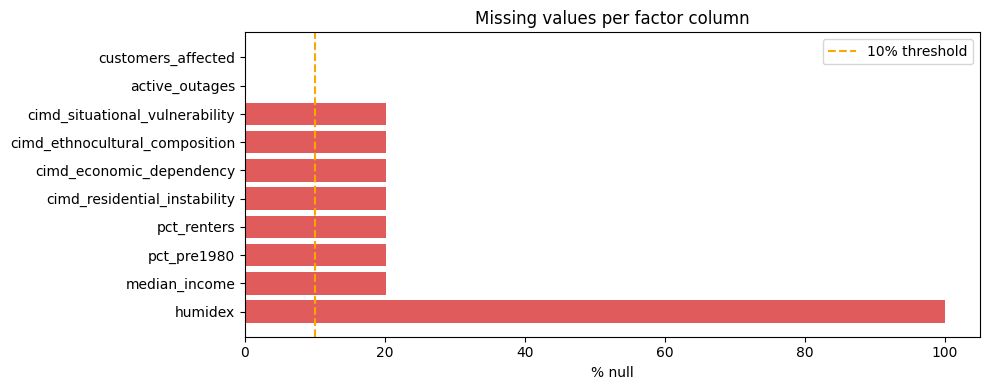

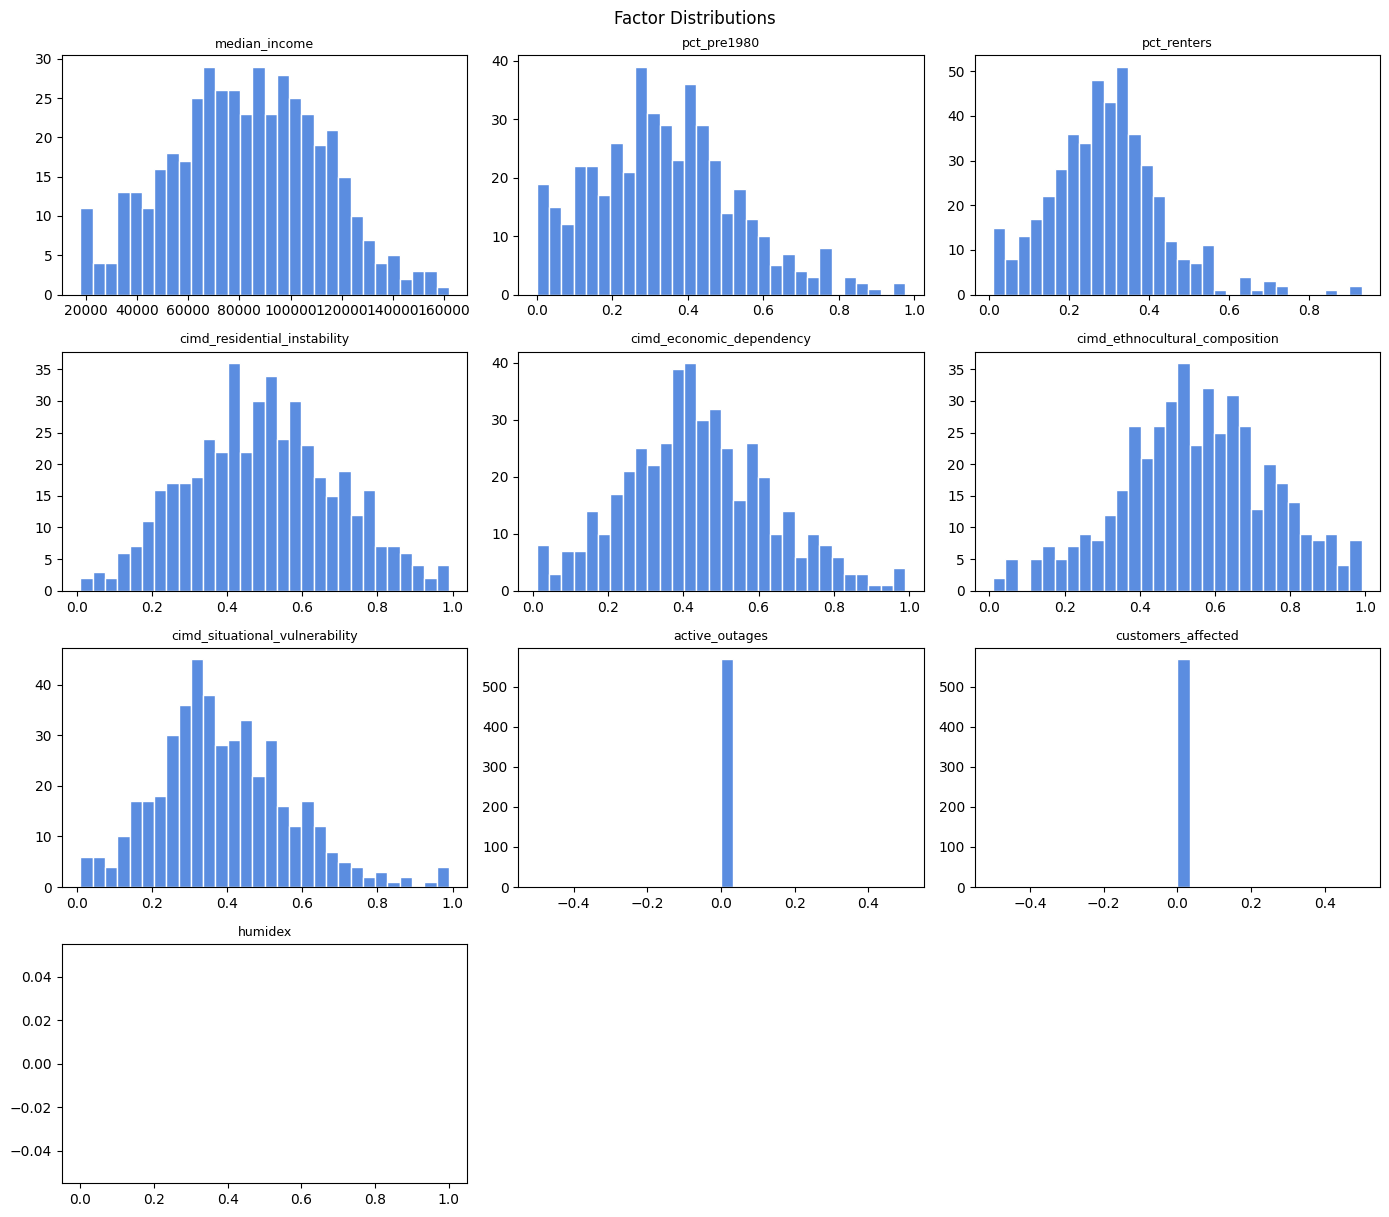

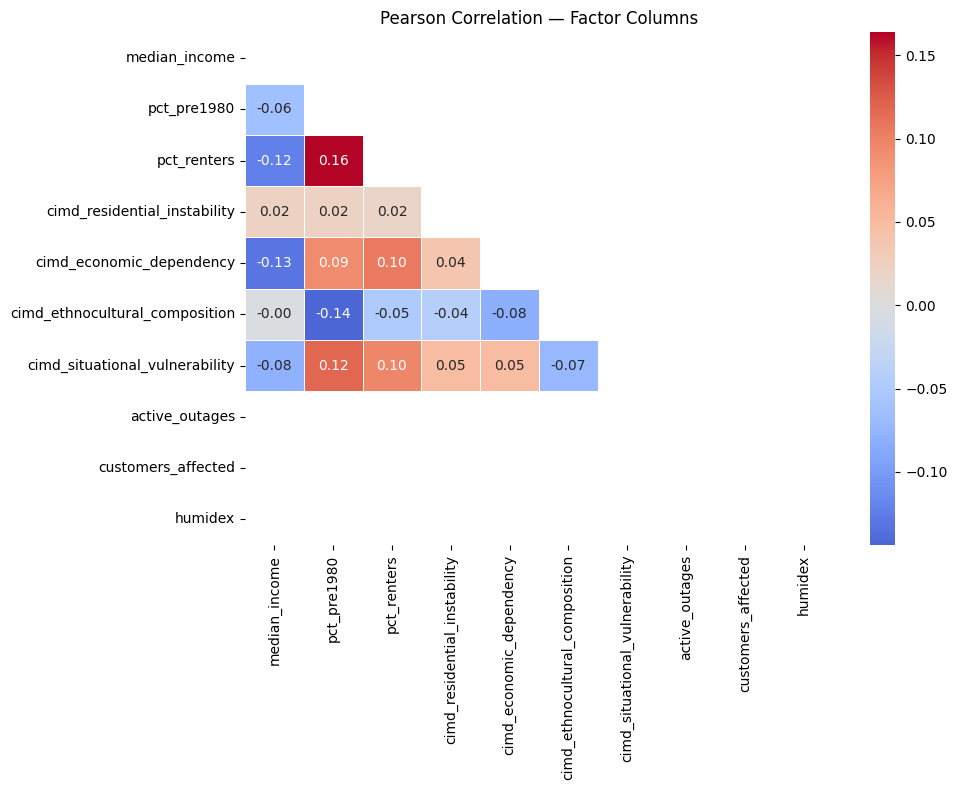


Factor summary stats:
       median_income  pct_pre1980  pct_renters  cimd_residential_instability  \
count         454.00       454.00       454.00                        454.00   
mean        82704.22         0.34         0.29                          0.49   
std         29646.89         0.19         0.14                          0.20   
min         18000.00         0.00         0.01                          0.01   
25%         63194.50         0.20         0.20                          0.36   
50%         83304.00         0.33         0.29                          0.49   
75%        104202.00         0.45         0.37                          0.63   
max        161773.00         0.98         0.93                          0.99   

       cimd_economic_dependency  cimd_ethnocultural_composition  \
count                    454.00                          454.00   
mean                       0.44                            0.55   
std                        0.19                        

In [17]:
# ── Section 3: Distributions & Data Quality ──────────────────────────────────

FACTOR_COLS = [
    "median_income", "pct_pre1980", "pct_renters",
    "cimd_residential_instability", "cimd_economic_dependency",
    "cimd_ethnocultural_composition", "cimd_situational_vulnerability",
    "active_outages", "customers_affected", "humidex",
]
available = [c for c in FACTOR_COLS if c in gdf_master.columns]
df_factors = gdf_master[available].copy()

# 3a: Missing value bar chart
null_pct = df_factors.isnull().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(null_pct.index, null_pct.values * 100, color="#e05b5b")
ax.axvline(10, color="orange", linestyle="--", label="10% threshold")
ax.set_xlabel("% null"); ax.set_title("Missing values per factor column")
ax.legend(); plt.tight_layout(); plt.show()

# 3b: Factor histograms
cols_n = 3
rows_n = (len(available) + cols_n - 1) // cols_n
fig2, axes2 = plt.subplots(rows_n, cols_n, figsize=(14, rows_n * 3))
axes2 = axes2.flatten()
for i, col in enumerate(available):
    axes2[i].hist(df_factors[col].dropna(), bins=30, color="#5b8de0", edgecolor="white")
    axes2[i].set_title(col, fontsize=9)
for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)
fig2.tight_layout()
fig2.suptitle("Factor Distributions", y=1.01, fontsize=12)
plt.show()

# 3c: Correlation matrix
corr = df_factors[available].corr()
fig3, ax3 = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax3)
ax3.set_title("Pearson Correlation — Factor Columns")
plt.tight_layout(); plt.show()

print("\nFactor summary stats:")
print(df_factors[available].describe().round(3))


CTs retained after null filter: 454
⚠️  Dropping zero-variance columns: ['active_outages', 'customers_affected', 'humidex']


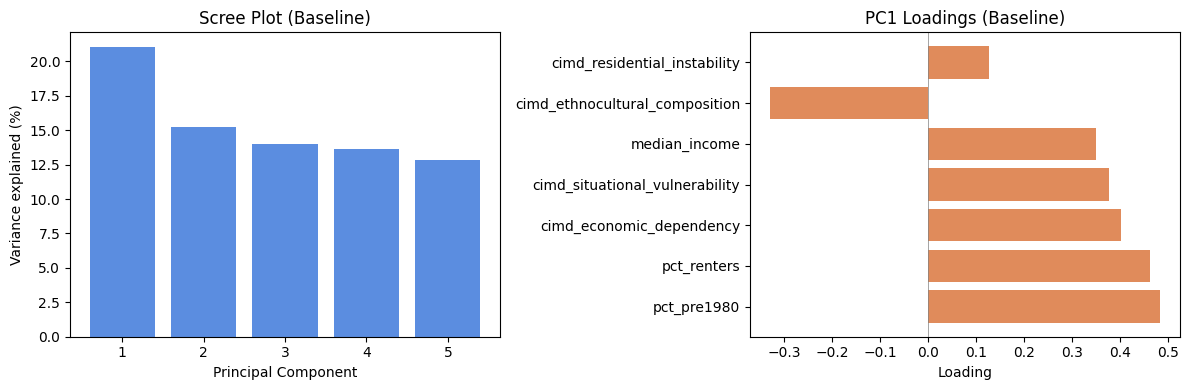

loadings.csv saved
Baseline PC1 explains: 21.1%


,factor,loading_baseline,loading_heatwave,loading_icestorm,source_slug
1,pct_pre1980,0.48,0.48,0.48,statcan-census-2021-ct-demographics
2,pct_renters,0.46,0.46,0.46,statcan-census-2021-ct-demographics
4,cimd_economic_dependency,0.40,0.40,0.40,statcan-cimd-2021
6,cimd_situational_vulnerability,0.38,0.38,0.38,statcan-cimd-2021
0,median_income,0.35,0.35,0.35,statcan-census-2021-ct-demographics
5,cimd_ethnocultural_composition,-0.33,-0.33,-0.33,statcan-cimd-2021
3,cimd_residential_instability,0.13,0.13,0.13,statcan-cimd-2021


In [18]:
# ── Section 4: PCA Threshold Score ───────────────────────────────────────────

FACTOR_COLS = [c for c in [
    "median_income", "pct_pre1980", "pct_renters",
    "cimd_residential_instability", "cimd_economic_dependency",
    "cimd_ethnocultural_composition", "cimd_situational_vulnerability",
    "active_outages", "customers_affected", "humidex",
] if c in gdf_master.columns]

df_pca = gdf_master[["CTUID"] + FACTOR_COLS].copy()

# Drop CTs missing >50% of factor columns
row_null_pct = df_pca[FACTOR_COLS].isnull().mean(axis=1)
df_pca = df_pca[row_null_pct <= 0.5].reset_index(drop=True)
print(f"CTs retained after null filter: {len(df_pca)}")

# Impute remaining NaN with column median; all-NaN columns get 0
medians = df_pca[FACTOR_COLS].median()
medians = medians.fillna(0)  # column is entirely NaN (e.g. no weather data) -> use 0
df_pca[FACTOR_COLS] = df_pca[FACTOR_COLS].fillna(medians)
# Drop any factor columns that remain all-zero (adds no signal to PCA)
zero_cols = [c for c in FACTOR_COLS if df_pca[c].std() == 0]
if zero_cols:
    print(f"⚠️  Dropping zero-variance columns: {zero_cols}")
    FACTOR_COLS = [c for c in FACTOR_COLS if c not in zero_cols]

# Invert income: lower income = higher vulnerability
df_pca["median_income"] = -df_pca["median_income"]

SOURCE_MAP = {
    "median_income":                  "statcan-census-2021-ct-demographics",
    "pct_pre1980":                    "statcan-census-2021-ct-demographics",
    "pct_renters":                    "statcan-census-2021-ct-demographics",
    "cimd_residential_instability":   "statcan-cimd-2021",
    "cimd_economic_dependency":       "statcan-cimd-2021",
    "cimd_ethnocultural_composition": "statcan-cimd-2021",
    "cimd_situational_vulnerability": "statcan-cimd-2021",
    "active_outages":                 "alectra-outages-live",
    "customers_affected":             "alectra-outages-live",
    "humidex":                        "envcan-geomet-current",
}

def run_pca_scenario(df, factor_cols, weights: dict = None):
    """Normalize columns, apply optional weights, return (PCA, scores 0-100)."""
    X = df[factor_cols].copy()
    if weights:
        for col, w in weights.items():
            if col in X.columns:
                X[col] = X[col] * w
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=min(5, len(factor_cols)))
    pca.fit(X_scaled)
    scores_raw = pca.transform(X_scaled)[:, 0]
    s_min, s_max = scores_raw.min(), scores_raw.max()
    scores_norm = (scores_raw - s_min) / (s_max - s_min) * 100
    return pca, scores_norm

# Baseline: equal weights
pca_baseline, scores_baseline = run_pca_scenario(df_pca, FACTOR_COLS)

# Heatwave: amplify heat/vulnerability factors
pca_heatwave, scores_heatwave = run_pca_scenario(
    df_pca, FACTOR_COLS,
    {"humidex": 2.5, "cimd_situational_vulnerability": 1.5, "pct_renters": 1.2}
)

# Ice Storm: amplify outage factors
pca_icestorm, scores_icestorm = run_pca_scenario(
    df_pca, FACTOR_COLS,
    {"active_outages": 3.0, "customers_affected": 2.0, "pct_renters": 1.5}
)

# Build scored GeoDataFrame
gdf_scored = gdf_master.merge(
    df_pca[["CTUID"]].assign(
        threshold_score_baseline=scores_baseline,
        threshold_score_heatwave=scores_heatwave,
        threshold_score_icestorm=scores_icestorm,
    ),
    on="CTUID", how="inner"
)

# Scree + loadings plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(1, len(pca_baseline.explained_variance_ratio_) + 1),
        pca_baseline.explained_variance_ratio_ * 100, color="#5b8de0")
ax1.set_xlabel("Principal Component"); ax1.set_ylabel("Variance explained (%)")
ax1.set_title("Scree Plot (Baseline)")

loadings_df = pd.DataFrame({
    "factor":            FACTOR_COLS,
    "loading_baseline":  pca_baseline.components_[0],
    "loading_heatwave":  pca_heatwave.components_[0],
    "loading_icestorm":  pca_icestorm.components_[0],
    "source_slug":       [SOURCE_MAP.get(c, "unknown") for c in FACTOR_COLS],
}).sort_values("loading_baseline", key=abs, ascending=False)

ax2.barh(loadings_df["factor"], loadings_df["loading_baseline"], color="#e08b5b")
ax2.axvline(0, color="grey", linewidth=0.5)
ax2.set_title("PC1 Loadings (Baseline)"); ax2.set_xlabel("Loading")
plt.tight_layout(); plt.show()

loadings_df.to_csv(DATA_DIR / "loadings.csv", index=False)
print(f"loadings.csv saved")
print(f"Baseline PC1 explains: {pca_baseline.explained_variance_ratio_[0]:.1%}")
loadings_df


In [19]:
# ASSERTION
assert "gdf_scored" in dir(), "gdf_scored not defined"
for col in ["threshold_score_baseline","threshold_score_heatwave","threshold_score_icestorm"]:
    assert col in gdf_scored.columns, f"Missing: {col}"
assert (DATA_DIR / "loadings.csv").exists(), "loadings.csv not written"
pc1_var = pca_baseline.explained_variance_ratio_[0]
assert pc1_var >= 0.15, f"PC1 explains only {pc1_var:.1%} — check factor columns"
print(f"✅ PCA assertions pass — PC1 explains {pc1_var:.1%} variance")
print(gdf_scored[["CTUID","threshold_score_baseline"]].describe())


✅ PCA assertions pass — PC1 explains 21.1% variance
       threshold_score_baseline
count                    454.00
mean                      43.11
std                       15.98
min                        0.00
25%                       33.15
50%                       41.60
75%                       51.13
max                      100.00


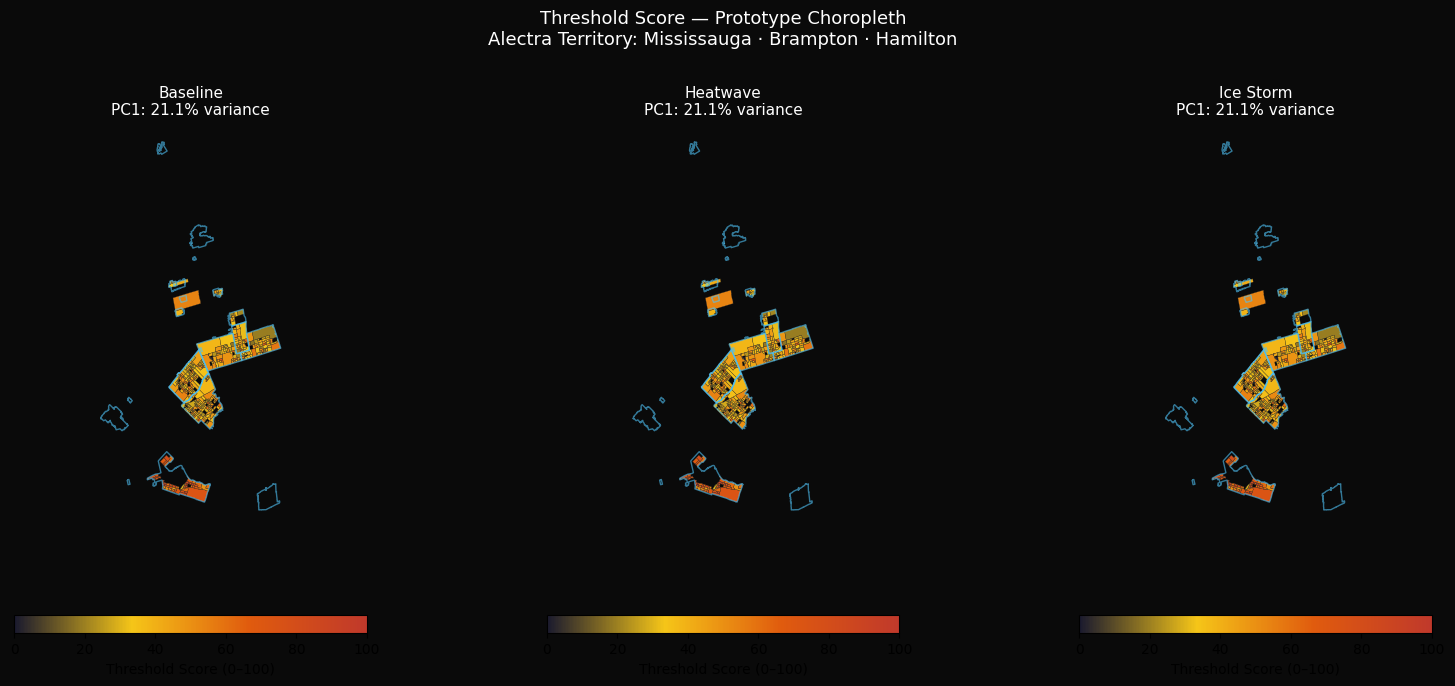

Saved prototype_choropleth.png


In [20]:
# ── Section 5: Prototype Choropleth ──────────────────────────────────────────

CMAP = mcolors.LinearSegmentedColormap.from_list(
    "threshold", ["#1a1a2e", "#f5c518", "#e05b0e", "#c0392b"]
)

scenarios = [
    ("threshold_score_baseline", "Baseline"),
    ("threshold_score_heatwave",  "Heatwave"),
    ("threshold_score_icestorm",  "Ice Storm"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor("#0a0a0a")

for ax, (score_col, title) in zip(axes, scenarios):
    ax.set_facecolor("#0a0a0a")
    if score_col not in gdf_scored.columns:
        ax.text(0.5, 0.5, f"{score_col}\nnot available",
                transform=ax.transAxes, ha="center", color="white")
        continue

    gdf_scored.plot(
        column=score_col, ax=ax, cmap=CMAP, vmin=0, vmax=100,
        linewidth=0.2, edgecolor="#333333",
        legend=True,
        legend_kwds={"shrink": 0.5, "label": "Threshold Score (0–100)",
                     "orientation": "horizontal"}
    )
    gdf_alectra.boundary.plot(ax=ax, color="#4fc3f7", linewidth=1.0, alpha=0.6)

    pca_obj = (pca_baseline if "baseline" in score_col
               else pca_heatwave if "heatwave" in score_col
               else pca_icestorm)
    pc_var = pca_obj.explained_variance_ratio_[0]
    ax.set_title(f"{title}\nPC1: {pc_var:.1%} variance", color="white", fontsize=11)
    ax.set_axis_off()

plt.suptitle("Threshold Score — Prototype Choropleth\n"
             "Alectra Territory: Mississauga · Brampton · Hamilton",
             color="white", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "prototype_choropleth.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved prototype_choropleth.png")


In [21]:
# ASSERTION
assert (DATA_DIR / "prototype_choropleth.png").exists(), "choropleth PNG not written"
print("✅ Choropleth written to pipeline/data/prototype_choropleth.png")


✅ Choropleth written to pipeline/data/prototype_choropleth.png
